In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()


True

In [3]:
from langchain_groq import ChatGroq
model = ChatGroq(
    model= "openai/gpt-oss-20b",
    temperature=1
)

In [4]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

TypeDict is for type check of the dictionary which is created during run time, in below code
we are extending or intiating dictionary with "messages" as keys and queries by the user as value


**TypedDict itself does not create any dictionaries.**

In [5]:
def chatbot(state: State):
    return {"messages" : [model.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph = graph_builder.compile()

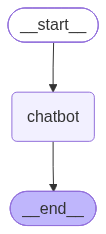

In [7]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
graph.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'chatbot': Node(id='chatbot', name='chatbot', data=chatbot(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='chatbot', data=None, conditional=False), Edge(source='chatbot', target='__end__', data=None, conditional=False)])

In [9]:
response = graph.invoke({"messages":"Hi"})
response["messages"][-1].content

'Hello! 👋 How can I help you today?'

In [10]:
for event in graph.stream({"messages":"Hi!"}):
    for response in event.values():
        print(response["messages"][-1].content)

Hey there! 👋 How can I help you today?


In [11]:
for event in graph.stream({"messages":"Hi!"}):
    print(event)
    print(event.values())

{'chatbot': {'messages': [AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to greeting.'}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 73, 'total_tokens': 99, 'completion_time': 0.026858496, 'completion_tokens_details': {'reasoning_tokens': 8}, 'prompt_time': 0.004998894, 'prompt_tokens_details': None, 'queue_time': 0.287908575, 'total_time': 0.03185739}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_565badff47', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fcb62-fd38-7612-8632-4e80b16c8517-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 26, 'total_tokens': 99, 'output_token_details': {'reasoning': 8}})]}}
dict_values([{'messages': [AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to greeting.'},

In [12]:
tavily_api_key = os.getenv("TAVILY_API_KEY")
from langchain_tavily import TavilySearch

In [13]:
tool = TavilySearch(tavily_api_key = tavily_api_key ,max_results = 2)
tool.invoke("What is a cat?")

{'query': 'What is a cat?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://bioart.niaid.nih.gov/bioart/601',
   'title': 'BioArt',
   'content': 'The domestic cat (Felis catus), also known as the house cat, is a small carnivorous mammal that has been domesticated. It is the only species within the Felidae family that has been domesticated. Through studies in archaeology and genetics, it has been determined that cats were domesticated in the Near East around 7500 BC. Cats are commonly kept as pets or farm animals but also live independently as feral creatures, often avoiding human interaction. Valued by people for their companionship and',
   'score': 0.7634314,
   'raw_content': None},
  {'url': 'https://www.ifaw.org/animals/cats',
   'title': 'Cats: Facts you need to know about domestic cats | IFAW',
   'content': '##### What is a cat?\n\nThe Felidae family includes everything from tigers, lions, cougars, ocelots, and lynxes to the domestic

In [14]:
def multiply(a : int, b : int):
    """Function to multiply two arguments of type integer.

    Args:
        a (int): first integer
        b (int): second integer
    """
    return a*b

In [15]:
tools = [tool,multiply]
chatbot_with_tools = model.bind_tools(tools)

In [16]:
chatbot_with_tools.invoke("What is the current weather in Vizianagaram")

AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants current weather in Vizianagaram. Need up-to-date weather. Should use tavily_search for real-time data.', 'tool_calls': [{'id': 'fc_e8a74ce4-e645-42f4-bada-d3054380d524', 'function': {'arguments': '{"query":"current weather in Vizianagaram","search_depth":"basic"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 356, 'total_tokens': 419, 'completion_time': 0.065560152, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.020146548, 'prompt_tokens_details': None, 'queue_time': 0.257498815, 'total_time': 0.0857067}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_2b688e7cc3', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fcb63-1418-7520-ad00-2224f0808082-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current weather in 

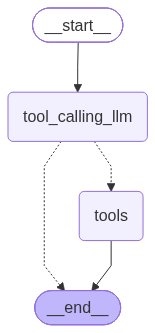

In [17]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state:State):
    return {"messages":[chatbot_with_tools.invoke(state["messages"])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response = graph.invoke({"messages":"Current AI news"})

In [19]:
response["messages"][-1].content

'{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.infoworld.com/article/4204427/hashimotos-superlogical-bets-that-agentic-software-development-needs-more-than-a-better-terminal.html", "title": "Hashimoto’s Superlogical bets that agentic software development needs more than a better terminal", "content": "Jul 30, 2026 4 mins\\n news\\n\\n  ### Model Context Protocol is going stateless to make scaling simpler\\n\\n  Jul 24, 2026 5 mins\\n news\\n\\n  ### Google CEO distracts from Gemini 3.5 Pro delay with talk of Gemini 4 and monthly releases\\n\\n  Jul 23, 2026 3 mins\\n news\\n\\n  ### Oracle expands Cloud@Customer with new database service for mid-sized workloads\\n\\n  Jul 22, 2026 5 mins\\n news\\n\\n  ### AWS standardizes more AI billing data to simplify cost analysis\\n\\n  Jul 21, 2026 3 mins\\n news\\n\\n  ### OpenAI’s Codex context reduction for GPT 5.6 sparks dissatisfaction among developers\\n\\n  Jul

In [20]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Current AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_5dcb056c-2032-47bf-bad6-cb00e2e8ec71)
 Call ID: fc_5dcb056c-2032-47bf-bad6-cb00e2e8ec71
  Args:
    query: latest AI news 2026
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.infoworld.com/article/4204427/hashimotos-superlogical-bets-that-agentic-software-development-needs-more-than-a-better-terminal.html", "title": "Hashimoto’s Superlogical bets that agentic software development needs more than a better terminal", "content": "Jul 30, 2026 4 mins\n news\n\n  ### Model Context Protocol is going stateless to make scaling simpler\n\n  Jul 24, 2026 5 mins\n news\n\

In [21]:
import json
data = json.loads(response["messages"][-1].content)
data

{'query': 'latest AI news 2026',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.infoworld.com/article/4204427/hashimotos-superlogical-bets-that-agentic-software-development-needs-more-than-a-better-terminal.html',
   'title': 'Hashimoto’s Superlogical bets that agentic software development needs more than a better terminal',
   'content': "Jul 30, 2026 4 mins\n news\n\n  ### Model Context Protocol is going stateless to make scaling simpler\n\n  Jul 24, 2026 5 mins\n news\n\n  ### Google CEO distracts from Gemini 3.5 Pro delay with talk of Gemini 4 and monthly releases\n\n  Jul 23, 2026 3 mins\n news\n\n  ### Oracle expands Cloud@Customer with new database service for mid-sized workloads\n\n  Jul 22, 2026 5 mins\n news\n\n  ### AWS standardizes more AI billing data to simplify cost analysis\n\n  Jul 21, 2026 3 mins\n news\n\n  ### OpenAI’s Codex context reduction for GPT 5.6 sparks dissatisfaction among developers\n\n  Jul 20, 2026 4 mins

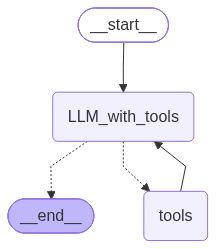

In [22]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    return {"messages": [chatbot_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("LLM_with_tools",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START,"LLM_with_tools")
builder.add_conditional_edges("LLM_with_tools",tools_condition)
builder.add_edge("tools","LLM_with_tools")
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_c9efe6ec-cfea-402b-88da-97f7771d3795)
 Call ID: fc_c9efe6ec-cfea-402b-88da-97f7771d3795
  Args:
    query: latest AI news 2026
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-may-2026", "title": "The latest AI news we announced in May 2026", "content": "May 2026 was packed with AI news. At Google I/O 2026, we officially entered the agentic Gemini era with the launch of Gemini 3.5 — which delivers frontier intelligence for agents and coding — and Gemini Omni, where Gemini’s ability to re

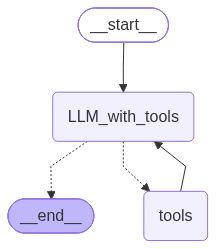

In [24]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()
def tool_calling_llm(state: State):
    return {"messages": [chatbot_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("LLM_with_tools",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START,"LLM_with_tools")
builder.add_conditional_edges("LLM_with_tools",tools_condition)
builder.add_edge("tools","LLM_with_tools")
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
config = {
    "configurable":{
        "thread_id": "1"
    }
}

In [29]:
reply = graph.invoke({"messages":"My name is Jayavardhan"},config= config)

In [31]:
reply["messages"][-1].content

'Nice to meet you, Jayavardhan! How can I help you today?'

In [32]:
test_reply = graph.invoke({"messages":"What is my name?"},config)
test_reply["messages"][-1].content

'Your name is Jayavardhan.'

**Streaming**

In [33]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

In [49]:
def tool_calling_llm(state:State):
    return {"messages":[model.invoke(state["messages"])]}

In [50]:
builder = StateGraph(State)
builder.add_node("ChatBot",tool_calling_llm)
builder.add_edge(START,"ChatBot")
builder.add_edge("ChatBot",END)

graph_test = builder.compile(checkpointer= memory)

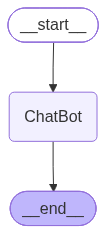

In [51]:
display(Image(graph_test.get_graph().draw_mermaid_png()))

In [54]:
config = {"configurable":{
    "thread_id":"3"
}}

In [55]:
reply = graph_test.invoke({"messages":"I am Jayavardhan and I love Engineering!"}, config = config)
reply

{'messages': [HumanMessage(content='I am Jayavardhan and I love Engineering!', additional_kwargs={}, response_metadata={}, id='ef4ab6db-0575-4151-9414-51650b7705d1'),
  AIMessage(content="Hey Jayavardhan! 👋 It's great to hear that you’re passionate about engineering. Whether you’re into mechanical, electrical, software, civil, or any other branch, there’s always something new and exciting to explore. What specific area of engineering gets your gears turning the most?", additional_kwargs={'reasoning_content': 'User says "I am Jayavardhan and I love Engineering!" Probably wants to respond. No special instructions. Just friendly.'}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 82, 'total_tokens': 176, 'completion_time': 0.12169826, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.003992235, 'prompt_tokens_details': None, 'queue_time': 0.313671404, 'total_time': 0.125690495}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'f

In [57]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_test.stream({'messages':"I am Jayavardhan and I love Engineering!"},config,stream_mode="updates"):
    print(chunk)

{'ChatBot': {'messages': [AIMessage(content="Hello Jayavardhan! 👋 It's great to hear that you love engineering. Whether you’re into mechanical, electrical, software, civil, aerospace, or any other branch, engineering offers endless opportunities for creativity and problem‑solving. \n\nWhat area(s) of engineering excite you the most, or are you exploring a new field right now? I'd love to hear more and maybe share some resources, projects, or industry trends that could spark inspiration!", additional_kwargs={'reasoning_content': "We need to respond to user. It's a greeting. We can acknowledge. Possibly ask about engineering interests."}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 82, 'total_tokens': 204, 'completion_time': 0.159715337, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.004347076, 'prompt_tokens_details': None, 'queue_time': 0.24878318, 'total_time': 0.164062413}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerpr

In [59]:
for chunk in graph_test.stream({'messages':"I am Jayavardhan and I love Engineering!"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='I am Jayavardhan and I love Engineering!', additional_kwargs={}, response_metadata={}, id='ef18d487-cf25-4423-a158-7cbe975843a7'), AIMessage(content="Hello Jayavardhan! 👋 It's great to hear that you love engineering. Whether you’re into mechanical, electrical, software, civil, aerospace, or any other branch, engineering offers endless opportunities for creativity and problem‑solving. \n\nWhat area(s) of engineering excite you the most, or are you exploring a new field right now? I'd love to hear more and maybe share some resources, projects, or industry trends that could spark inspiration!", additional_kwargs={'reasoning_content': "We need to respond to user. It's a greeting. We can acknowledge. Possibly ask about engineering interests."}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 82, 'total_tokens': 204, 'completion_time': 0.159715337, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.0043470

In [61]:
response_test = graph_test.invoke({"messages":"What's my name and what do I like?"},config = config)
response_test

{'messages': [HumanMessage(content='I am Jayavardhan and I love Engineering!', additional_kwargs={}, response_metadata={}, id='ef18d487-cf25-4423-a158-7cbe975843a7'),
  AIMessage(content="Hello Jayavardhan! 👋 It's great to hear that you love engineering. Whether you’re into mechanical, electrical, software, civil, aerospace, or any other branch, engineering offers endless opportunities for creativity and problem‑solving. \n\nWhat area(s) of engineering excite you the most, or are you exploring a new field right now? I'd love to hear more and maybe share some resources, projects, or industry trends that could spark inspiration!", additional_kwargs={'reasoning_content': "We need to respond to user. It's a greeting. We can acknowledge. Possibly ask about engineering interests."}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 82, 'total_tokens': 204, 'completion_time': 0.159715337, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.00434

we do have astream too